<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn15tl_flowers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

(train_ds, val_ds), ds_info = tfds.load(
    'tf_flowers',
    split = ['train[:80%]', 'train[80%:]'],
    shuffle_files = True,
    as_supervised = True, # tuple 형태로 반환
    with_info = True
)

for image, label in train_ds.take(1):
  print(type(image), type(label))

print(ds_info.features['label'].names) # ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.K9WXFA_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [ ]:
# 전처리
# 이미지는 정규화가 잘 나오지만 표준화가 더 잘 나올때도 있어서 둘다 진행해보는게 좋다.

IMG_SIZE = (160, 160)
BATCH_SIZE = 32 # 32개씩 순차적으로 CPU/GPU에 순차적으로 올려서 진행하겠다

def preprocessFunc(image, label):
  # img 사이즈 통일
  image = tf.image.resize(image, IMG_SIZE)
  # 정규화
  image = tf.cast(image, tf.float32) / 255.0
  return image, label


train_ds = train_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Base Model(백본모델) 불러오기
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3, ), # (160, 160, 3) 튜플로 줘야함!
    include_top = False,
    weights = 'imagenet'
)
base_model.trainalbe = False

# 내가 사용할 Model
model = tf.keras.Sequential([
    base_model, # 학습에 참여 없이 특징 추출기 역할만 함.
    layers.GlobalAveragePooling2D(),
    layers.Dense(units=128, activation = 'relu'),
    layers.Dense(units=ds_info.features['label'].num_classes, activation = 'softmax')
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

print(base_model.summary())
print(model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 2,388,485 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [ ]:
model.fit(
    train_ds, validation_data = val_ds, epochs = 5, verbose = 1)

loss, acc = model.evaluate(val_ds)
print(f'loss : {loss:.4f}, acc : {acc:.4f}')

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 124s 665ms/step - accuracy: 0.7977 - loss: 0.5872 - val_accuracy: 0.4714 - val_loss: 6.2685
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8791 - loss: 0.3564 - val_accuracy: 0.5722 - val_loss: 5.5311
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9033 - loss: 0.2854 - val_accuracy: 0.6158 - val_loss: 3.1337
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9223 - loss: 0.2311 - val_accuracy: 0.5599 - val_loss: 5.0110
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9465 - loss: 0.1775 - val_accuracy: 0.6975 - val_loss: 2.6547
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6975 - loss: 2.6547
loss : 2.6547, acc : 0.6975


In [ ]:
# 다음단계 - 미세조정(Fine Tunning)
# base model의 일부 layer를 학습에 참여
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-6), # 학습률 낮추기!
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
print('Fine Tunning 시작')

model.fit(
    train_ds, validation_data = val_ds, epochs = 5, verbose = 1)

loss, acc = model.evaluate(val_ds)
print(f'Fine Tunning loss : {loss:.4f}, acc : {acc:.4f}')

Fine Tunning 시작
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 259ms/step - accuracy: 0.8753 - loss: 0.4157 - val_accuracy: 0.7520 - val_loss: 2.0849
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8787 - loss: 0.3971 - val_accuracy: 0.7711 - val_loss: 1.7412
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8811 - loss: 0.3800 - val_accuracy: 0.7902 - val_loss: 1.4993
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8859 - loss: 0.3644 - val_accuracy: 0.8038 - val_loss: 1.3167
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8900 - loss: 0.3500 - val_accuracy: 0.8215 - val_loss: 1.1727
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8215 - loss: 1.1727
Fine Tunning loss : 1.1727, acc : 0.8215


In [ ]:
# 검증 데이터셋에서 이미지 1개 추출후 예측하기
for image, label in val_ds.take(1):
  sample_image = image
  sample_label = label
  break

pred_probs = model.predict(sample_image)
print(pred_probs)

pred_classes  = tf.argmax(pred_probs, axis = 1)
print(pred_classes)

print(sample_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[[6.02291664e-04 1.81328593e-04 1.97076285e-03 4.26411862e-06
  9.97241378e-01]
 [3.32419859e-15 9.43440812e-11 9.99999523e-01 1.27789651e-16
  4.95903578e-07]
 [4.41104894e-05 4.24463542e-06 4.26957637e-01 5.72968006e-01
  2.59750268e-05]
 [2.44176234e-13 4.15727941e-09 9.95087087e-01 1.10033876e-13
  4.91291098e-03]
 [5.66421913e-05 9.99845266e-01 9.76728479e-05 9.75356329e-09
  4.40299317e-07]
 [9.99965668e-01 1.06152647e-05 1.29805803e-05 8.13271345e-06
  2.60278466e-06]
 [9.75694895e-01 2.37619262e-02 4.83602867e-04 1.89655509e-07
  5.93202531e-05]
 [6.31519813e-16 4.41915905e-12 9.99999285e-01 1.64175201e-17
  7.39338077e-07]
 [6.57337029e-09 1.26544419e-08 4.34014237e-06 9.99995589e-01
  6.22773055e-10]
 [3.01658824e-14 4.03063104e-11 2.39748369e-12 1.00000000e+00
  9.29468396e-15]
 [1.27850319e-06 2.37253742e-04 7.76949048e-01 5.08728317e-06
  2.22807333e-01]
 [1.12061789e-05 3.56690749e-03 1.61939010e-04 9.96259749e-01
  1.09254877e-07]
 [4.

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
[00] pred : 4 (roses), actual : 4 (roses)
[01] pred : 2 (tulips), actual : 2 (tulips)
[02] pred : 3 (sunflowers), actual : 2 (tulips)
[03] pred : 2 (tulips), actual : 2 (tulips)
[04] pred : 1 (daisy), actual : 1 (daisy)
[05] pred : 0 (dandelion), actual : 1 (daisy)
[06] pred : 0 (dandelion), actual : 1 (daisy)
[07] pred : 2 (tulips), actual : 2 (tulips)
[08] pred : 3 (sunflowers), actual : 3 (sunflowers)
[09] pred : 3 (sunflowers), actual : 3 (sunflowers)
[10] pred : 2 (tulips), actual : 4 (roses)
[11] pred : 3 (sunflowers), actual : 3 (sunflowers)
[12] pred : 3 (sunflowers), actual : 3 (sunflowers)
[13] pred : 2 (tulips), actual : 2 (tulips)
[14] pred : 2 (tulips), actual : 2 (tulips)
[15] pred : 0 (dandelion), actual : 0 (dandelion)
[16] pred : 2 (tulips), actual : 2 (tulips)
[17] pred : 0 (dandelion), actual : 0 (dandelion)
[18] pred : 3 (sunflowers), actual : 3 (sunflowers)
[19] pred : 0 (dandelion), actual : 0 (dandelion)
[20

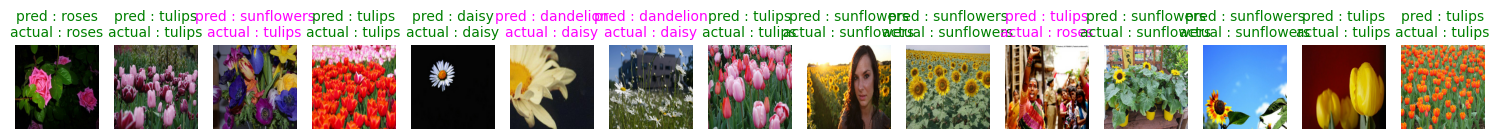

In [ ]:
# 클래스 이름 얻기
class_names = ds_info.features['label'].names
print(class_names)

# 예측값과 실제값 출력
for i in range(len(sample_image)):
  predict_index = int(pred_classes[i])
  actual_index = int(sample_label[i])

  predict_name = class_names[predict_index]
  actual_name = class_names[actual_index]

  print(f'[{i:02}] pred : {predict_index} ({predict_name}), actual : {actual_index} ({actual_name})')

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
for i in range(15):
  plt.subplot(1, 15, i+1)
  plt.imshow(sample_image[i])

  predicted_label = class_names[pred_classes[i]]
  actual_label = class_names[sample_label[i]]

  color = 'green' if predicted_label == actual_label else 'magenta'
  plt.title(f'pred : {predicted_label}\nactual : {actual_label}', color = color, fontsize=10)
  plt.axis('off')
plt.tight_layout()
plt.show()